In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

# Load dataset
df = pd.read_csv('netflix_titles.csv')

# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

# Drop rows where date_added is missing (only 10)
df.dropna(subset=['date_added'], inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Extract year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print('✅ Data cleaned!')
print('Shape:', df.shape)
df.head()

✅ Data cleaned!
Shape: (8797, 14)


/tmp/ipykernel_2133/4280309173.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_2133/4280309173.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [2]:
# Summary statistics
print('=== CONTENT TYPE BREAKDOWN ===')
print(df['type'].value_counts())

print('\n=== RATING BREAKDOWN ===')
print(df['rating'].value_counts())

print('\n=== RELEASE YEAR RANGE ===')
print('Earliest:', df['release_year'].min())
print('Latest:', df['release_year'].max())

print('\n=== TOP 10 COUNTRIES ===')
print(df['country'].value_counts().head(10))

print('\n=== NUMERIC SUMMARY ===')
print(df[['release_year', 'year_added']].describe())

=== CONTENT TYPE BREAKDOWN ===
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

=== RATING BREAKDOWN ===
rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

=== RELEASE YEAR RANGE ===
Earliest: 1925
Latest: 2021

=== TOP 10 COUNTRIES ===
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

=== NUMERIC SUMMARY ===
       release_year   year_added
count   8797.000000  8797.000000
mean    2014.183472  2018.871888
std        8.822191     1.574243
min     1925.000000 

In [3]:
print('=== CONTENT TYPE BREAKDOWN ===')
print(df['type'].value_counts())

print('\n=== RATING BREAKDOWN ===')
print(df['rating'].value_counts())

print('\n=== RELEASE YEAR RANGE ===')
print('Earliest:', df['release_year'].min())
print('Latest:', df['release_year'].max())

print('\n=== TOP 10 COUNTRIES ===')
print(df['country'].value_counts().head(10))

print('\n=== NUMERIC SUMMARY ===')
print(df[['release_year', 'year_added']].describe())

=== CONTENT TYPE BREAKDOWN ===
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

=== RATING BREAKDOWN ===
rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64

=== RELEASE YEAR RANGE ===
Earliest: 1925
Latest: 2021

=== TOP 10 COUNTRIES ===
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

=== NUMERIC SUMMARY ===
       release_year   year_added
count   8797.000000  8797.000000
mean    2014.183472  2018.871888
std        8.822191     1.574243
min     1925.000000 

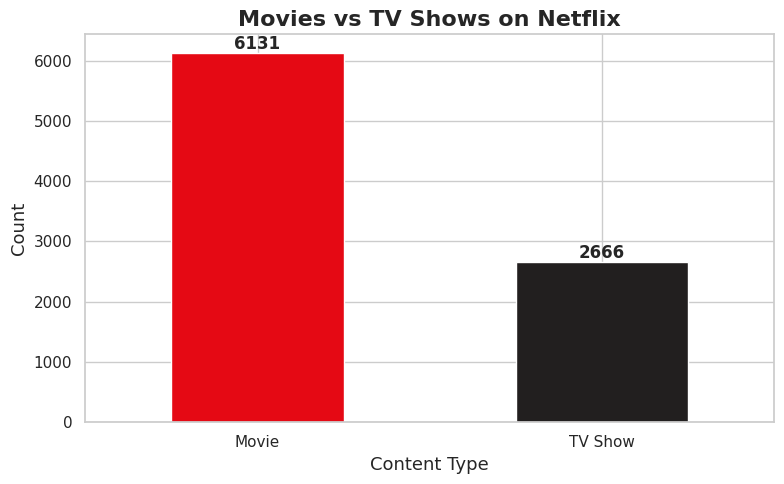

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E50914', '#221F1F']
df['type'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5)
ax.set_title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Content Type', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png', dpi=150)
plt.show()

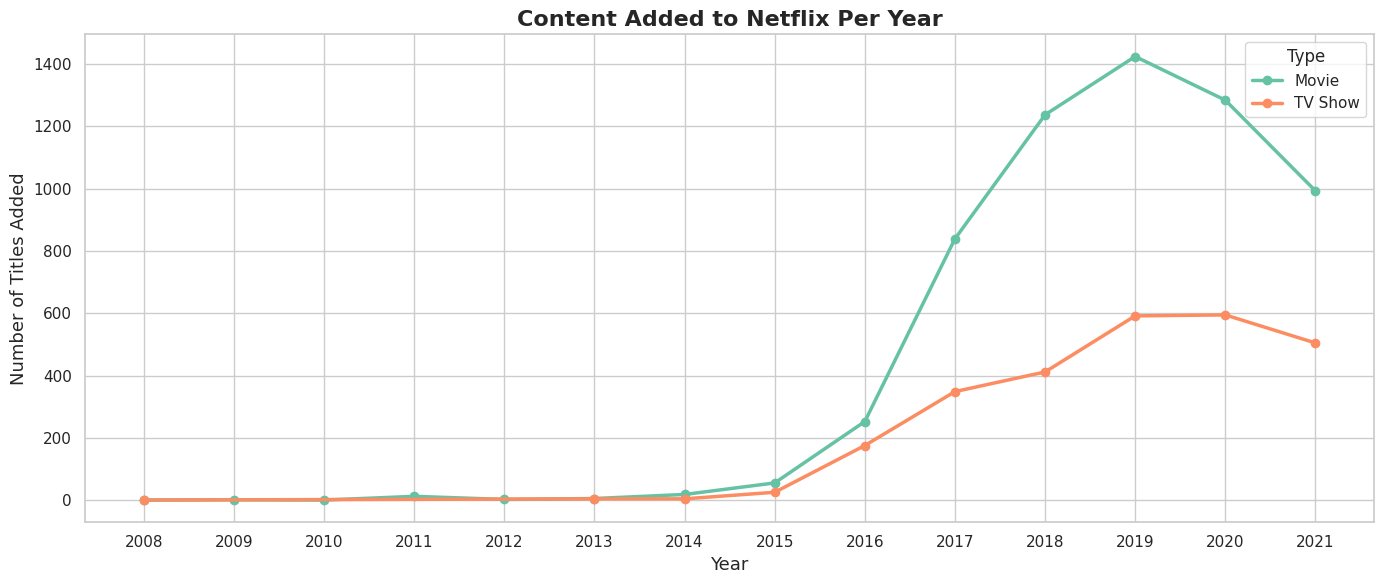

In [5]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 6))
for content_type, group in yearly.groupby('type'):
    ax.plot(group['year_added'], group['count'], marker='o', linewidth=2.5, label=content_type)
ax.set_title('Content Added to Netflix Per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Titles Added', fontsize=13)
ax.legend(title='Type', fontsize=11)
ax.set_xticks(yearly['year_added'].unique())
plt.tight_layout()
plt.savefig('content_trend_per_year.png', dpi=150)
plt.show()

/tmp/ipykernel_2133/2387744851.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=ax)


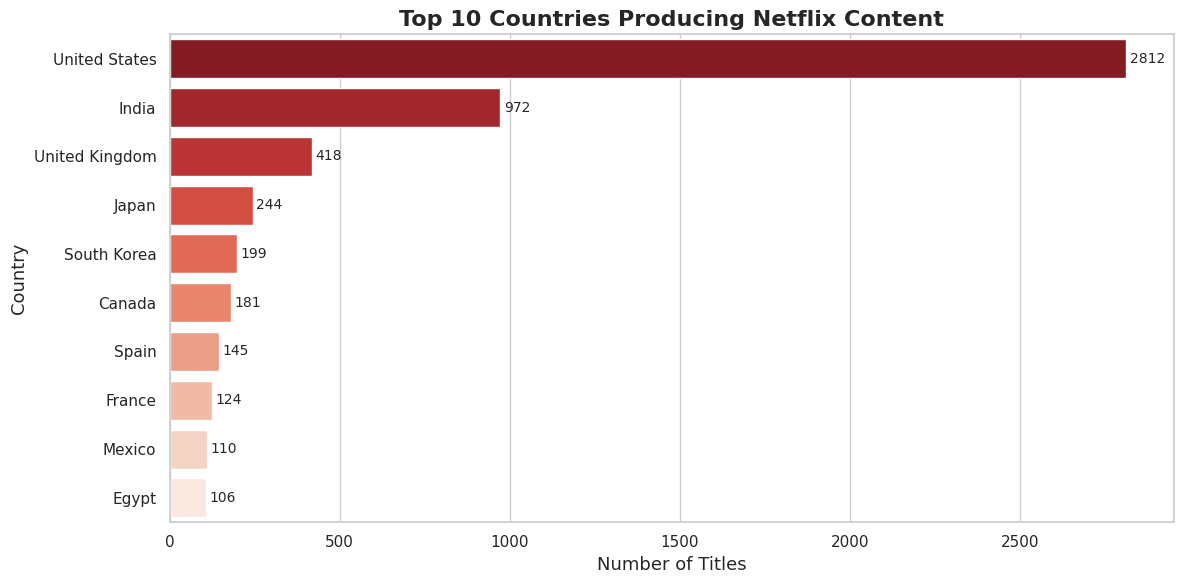

In [6]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=ax)
ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=13)
ax.set_ylabel('Country', fontsize=13)
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

/tmp/ipykernel_2133/3527534792.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='coolwarm', ax=ax)


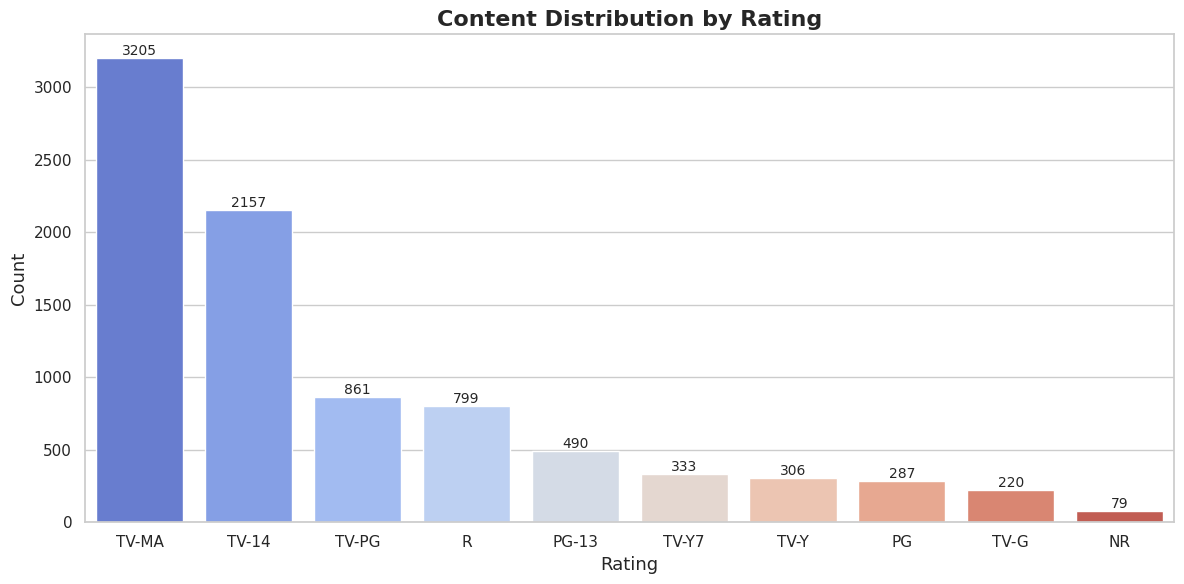

In [7]:
top_ratings = df['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='coolwarm', ax=ax)
ax.set_title('Content Distribution by Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('ratings_distribution.png', dpi=150)
plt.show()

/tmp/ipykernel_2133/2819358814.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r', ax=ax)


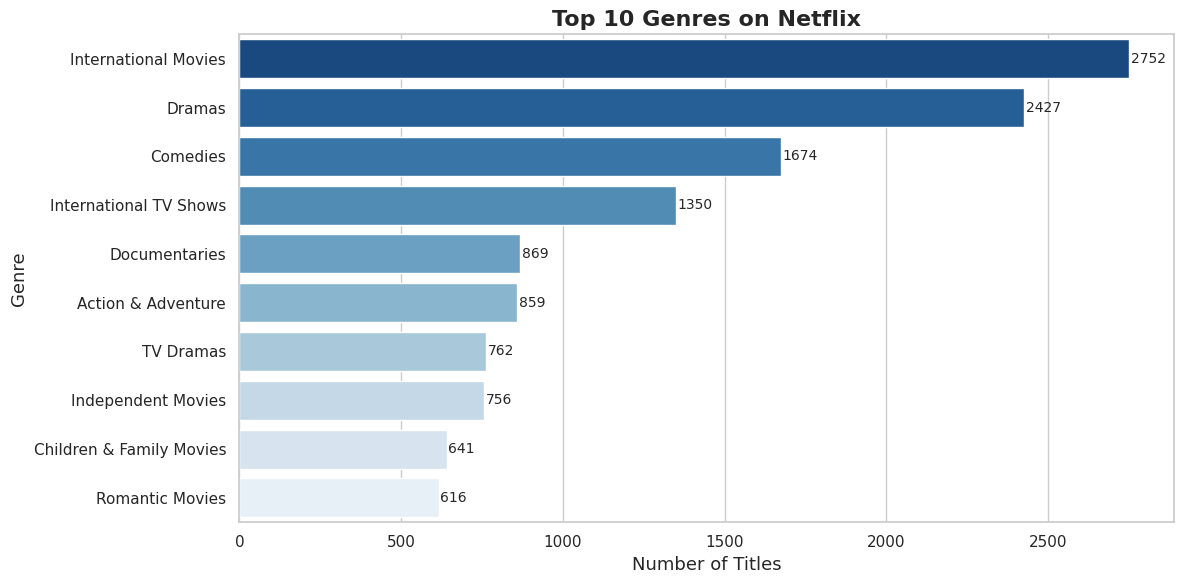

In [8]:
from collections import Counter

genres = df['listed_in'].str.split(', ').explode()
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=13)
ax.set_ylabel('Genre', fontsize=13)
for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150)
plt.show()

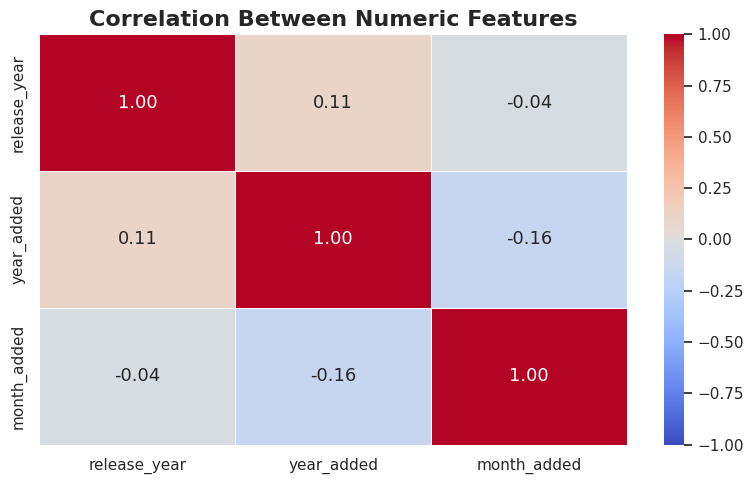

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df[['release_year', 'year_added', 'month_added']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 13}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Between Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_netflix.png', dpi=150)
plt.show()